Class
0    284315
1       492
Name: count, dtype: int64


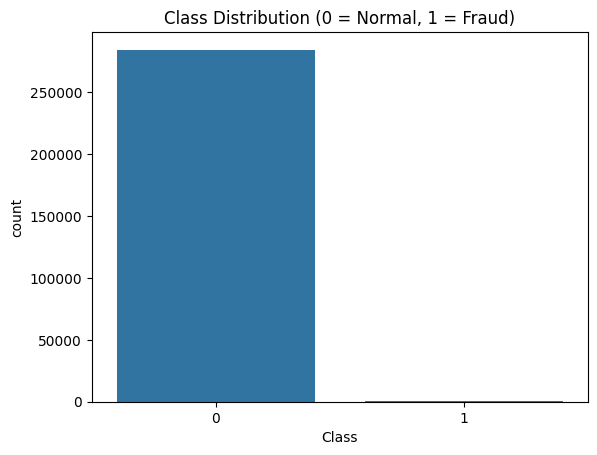

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Training size: (227845, 30)
Testing size: (56962, 30)
Before SMOTE: [227451    394]
After SMOTE: [227451 227451]


In [ ]:
from google.colab import files
import io # Import io module

# Read the uploaded CSV file into a DataFrame directly from the content directory
df = pd.read_csv('/content/creditcard (1).csv')

# Convert 'Class' column to integer type
df['Class'] = df['Class'].astype(int)

!pip install imbalanced-learn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

from imblearn.over_sampling import SMOTE
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()
print(df.isnull().sum())
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", np.bincount(y_train_smote))
iso = IsolationForest(contamination=0.01, random_state=42)

iso.fit(X_train_scaled)

train_anomaly_score = iso.decision_function(X_train_scaled)
test_anomaly_score = iso.decision_function(X_test_scaled)
X_train_hybrid = np.column_stack((X_train_scaled, train_anomaly_score))
X_test_hybrid = np.column_stack((X_test_scaled, test_anomaly_score))
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier()

log_model.fit(X_train_smote, y_train_smote)
rf_model.fit(X_train_smote, y_train_smote)
log_hybrid = LogisticRegression(max_iter=1000)
rf_hybrid = RandomForestClassifier()

log_hybrid.fit(X_train_hybrid, y_train)
rf_hybrid.fit(X_train_hybrid, y_train)
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    return precision, recall, f1, roc
log_results = evaluate_model(log_model, X_test_scaled, y_test)
rf_results = evaluate_model(rf_model, X_test_scaled, y_test)

print("Logistic Regression:", log_results)
print("Random Forest:", rf_results)
log_hybrid_results = evaluate_model(log_hybrid, X_test_hybrid, y_test)
rf_hybrid_results = evaluate_model(rf_hybrid, X_test_hybrid, y_test)

print("Hybrid Logistic Regression:", log_hybrid_results)
print("Hybrid Random Forest:", rf_hybrid_results)
y_pred = rf_hybrid.predict(X_test_hybrid)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Hybrid Random Forest")
plt.show()
y_prob = rf_hybrid.predict_proba(X_test_hybrid)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Hybrid Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Hybrid Logistic Regression",
        "Hybrid Random Forest"
    ],
    "Precision": [
        log_results[0],
        rf_results[0],
        log_hybrid_results[0],
        rf_hybrid_results[0]
    ],
    "Recall": [
        log_results[1],
        rf_results[1],
        log_hybrid_results[1],
        rf_hybrid_results[1]
    ],
    "F1 Score": [
        log_results[2],
        rf_results[2],
        log_hybrid_results[2],
        rf_hybrid_results[2]
    ],
    "ROC-AUC": [
        log_results[3],
        rf_results[3],
        log_hybrid_results[3],
        rf_hybrid_results[3]
    ]
})

print(results)
print("Hybrid models use anomaly detection + supervised learning.")
print("They often perform better for fraud detection because fraud cases are rare.")